# 使用完全連接層估算簡單線性迴歸的參數w、b

In [1]:
# 載入套件
from typing import cast

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn, optim
from sklearn.linear_model import LinearRegression

## 產生隨機資料

In [2]:
# 產生線性隨機資料100筆，介於 0-50
n = 100
X = np.linspace(0, 50, n)
y = np.linspace(0, 50, n)

# 資料加一點雜訊(noise)
X += np.random.uniform(-10, 10, n)
y += np.random.uniform(-10, 10, n)

## 定義模型

In [3]:
# 定義模型
def create_model(input_feature: int, output_feature: int):
    model = nn.Sequential(
        nn.Linear(input_feature, output_feature),
        nn.Flatten(0, -1), # 所有維度轉成一維 
    )
    return model

## 定義訓練函數

In [ ]:
def train(
    X: torch.Tensor,
    y: torch.Tensor,
    epochs: int = 100,
    lr: float = 1e-4,
) -> tuple[list[float], list[float], list[float]]:
    model = create_model(1, 1)

    # 定義損失函數
    loss_fn = nn.MSELoss(reduction='sum')

    # 定義優化器
    optimizer = optim.Adam(model.parameters(), lr=lr)

    loss_list: list[float] = []
    w_list: list[float] = []
    b_list: list[float] = []
    for epoch in range(epochs):  # 執行訓練週期
        y_pred: torch.Tensor = model(X)  # 預測值

        # 計算損失函數值
        # print(y_pred.shape, y.shape)
        MSE = loss_fn.forward(y_pred, y)

        # 梯度重置：改由優化器(Optimizer)控制
        optimizer.zero_grad()

        # 反向傳導
        MSE.backward()

        # 權重更新：改用 model.parameters 取代 w、b 逐一更新
        optimizer.step()

        # 記錄訓練結果
        linear_layer = cast(nn.Linear, model[0])
        if (epoch + 1) % 1000 == 0 or epochs < 1000:
            w_list.append(linear_layer.weight[:, 0].item())  # w.item()：轉成常數
            b_list.append(linear_layer.bias.item())
            loss_list.append(MSE.item())

    return w_list, b_list, loss_list

## 執行訓練

In [5]:
# 使用不同學習率及更多的執行週期訓練
X2, y2 = torch.FloatTensor(X.reshape(X.shape[0], 1)), torch.FloatTensor(y)
w_list, b_list, loss_list = train(X2, y2, epochs=10**5, lr=1e-5)

# 取得 w、b 的最佳解
print(f'w={w_list[-1]}, b={b_list[-1]}')

w=0.38666343688964844, b=0.03567768633365631


In [6]:
# 執行訓練
coef = np.polyfit(X, y, deg=1)

# 取得 w、b 的最佳解
print(f'w={coef[0]}, b={coef[1]}')

w=0.9270401091467234, b=1.164251091992821


In [7]:
from sklearn.linear_model import LinearRegression

X2 = X.reshape(X.shape[0], 1)

lr = LinearRegression()
lr.fit(X2, y)

lr.coef_[0], lr.intercept_

(np.float64(0.9270401091467232), np.float64(1.164251091992817))

## 顯示迴歸線

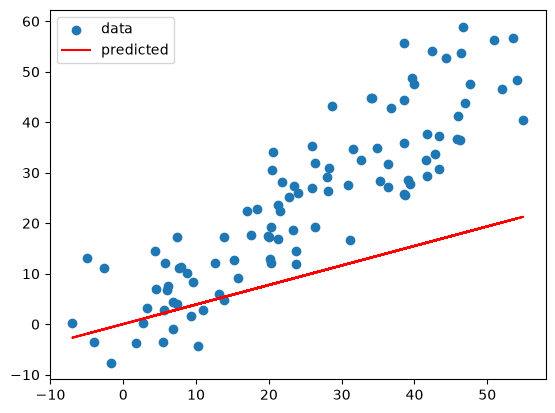

In [8]:
plt.scatter(X, y, label='data')
plt.plot(X, w_list[-1] * X + b_list[-1], 'r-', label='predicted')
plt.legend()

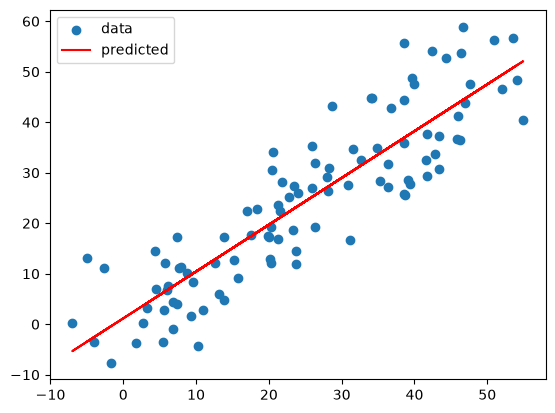

In [9]:
# NumPy 求得的迴歸線
plt.scatter(X, y, label='data')
plt.plot(X, coef[0] * X + coef[1], 'r-', label='predicted')
plt.legend()

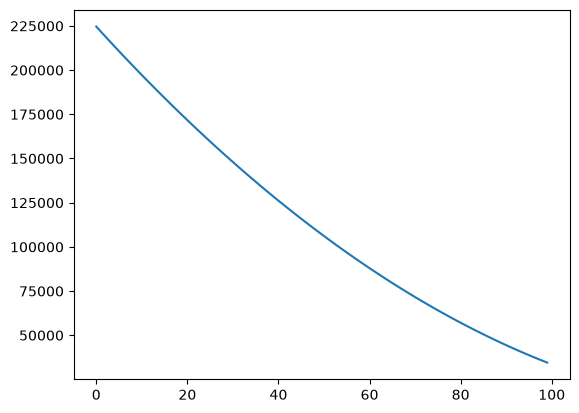

In [10]:
# 損失函數繪圖
plt.plot(loss_list)

In [11]:
loss_list

[224617.6875,
 221793.015625,
 218986.703125,
 216198.71875,
 213429.09375,
 210677.828125,
 207944.90625,
 205230.34375,
 202534.140625,
 199856.265625,
 197201.484375,
 194567.9375,
 191952.65625,
 189355.625,
 186776.8125,
 184216.28125,
 181673.96875,
 179149.9375,
 176644.125,
 174156.546875,
 171687.234375,
 169236.15625,
 166803.328125,
 164388.75,
 161992.421875,
 159614.34375,
 157254.78125,
 154913.5625,
 152590.59375,
 150285.875,
 147999.390625,
 145731.140625,
 143481.125,
 141249.359375,
 139035.84375,
 136840.546875,
 134663.5,
 132506.65625,
 130369.1875,
 128249.8984375,
 126148.7890625,
 124065.875,
 122001.140625,
 119954.5859375,
 117926.2265625,
 115916.015625,
 113923.859375,
 111949.90625,
 109994.296875,
 108056.875,
 106137.640625,
 104237.09375,
 102355.59375,
 100492.25,
 98647.0625,
 96820.046875,
 95011.171875,
 93220.640625,
 91448.5859375,
 89694.859375,
 87959.4453125,
 86242.375,
 84543.609375,
 82863.125,
 81200.984375,
 79557.28125,
 77931.6875,
 7632

In [12]:
w_list

[-0.5934760570526123,
 -0.5835220813751221,
 -0.5735681056976318,
 -0.5636141300201416,
 -0.5536601543426514,
 -0.5437061786651611,
 -0.5337522029876709,
 -0.5237982273101807,
 -0.5138442516326904,
 -0.5038902759552002,
 -0.49395447969436646,
 -0.4840303063392639,
 -0.4741061329841614,
 -0.46418195962905884,
 -0.4542577862739563,
 -0.44433361291885376,
 -0.4344094395637512,
 -0.4244852662086487,
 -0.41456109285354614,
 -0.4046369194984436,
 -0.39471274614334106,
 -0.3847885727882385,
 -0.374864399433136,
 -0.36494022607803345,
 -0.3550160527229309,
 -0.34509187936782837,
 -0.33516770601272583,
 -0.3252435326576233,
 -0.31531935930252075,
 -0.3053951859474182,
 -0.2954710125923157,
 -0.28554683923721313,
 -0.2756226658821106,
 -0.26569849252700806,
 -0.2557743191719055,
 -0.24585014581680298,
 -0.23592597246170044,
 -0.2260112166404724,
 -0.21610194444656372,
 -0.20619267225265503,
 -0.19628340005874634,
 -0.18637412786483765,
 -0.17646485567092896,
 -0.16655558347702026,
 -0.1566463112

In [13]:
b_list

[-0.944452702999115,
 -0.9344987273216248,
 -0.9245447516441345,
 -0.9145907759666443,
 -0.904636800289154,
 -0.8946828246116638,
 -0.8847288489341736,
 -0.8747748732566833,
 -0.8648208975791931,
 -0.8548669219017029,
 -0.8449129462242126,
 -0.8349589705467224,
 -0.8250049948692322,
 -0.8150510191917419,
 -0.8050970435142517,
 -0.7951430678367615,
 -0.7851890921592712,
 -0.775235116481781,
 -0.7652811408042908,
 -0.7553271651268005,
 -0.7453731894493103,
 -0.7354192137718201,
 -0.7254652380943298,
 -0.7155112624168396,
 -0.7055572867393494,
 -0.6956033110618591,
 -0.6856926679611206,
 -0.6757982969284058,
 -0.6659039258956909,
 -0.6560095548629761,
 -0.6461151838302612,
 -0.6362208127975464,
 -0.6263264417648315,
 -0.6164320707321167,
 -0.6065376996994019,
 -0.596643328666687,
 -0.5867489576339722,
 -0.5768545866012573,
 -0.5669602155685425,
 -0.5570658445358276,
 -0.5471714735031128,
 -0.537277102470398,
 -0.5273827314376831,
 -0.5174883604049683,
 -0.5075939893722534,
 -0.49769267439